In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def intensity(x,y, args):
    E0, lambda0, z0, a , b, c = args
    arg_a = (a*x)/(lambda0*z0)
    arg_b = (a*y)/(lambda0*z0)
    arg_c = (np.pi*c*x)/(lambda0*z0)
    amp = 2*E0*a*b
    E = amp*np.sinc(arg_a)*np.sinc(arg_b)*np.cos(arg_c)
    return E**2

In [3]:
# definimos las variables
E0 = 1
lambda0 = 543e-9 #[m]
z0 = 1 #L [m]
a = 20e-6 #[m]
b = 2*a
c = 4*a

args = [E0, lambda0, z0, a , b, c]

In [4]:
''' Gráfica de I(x,0) e I(0,y)'''
def plot_axes(args, lim = 1, resolution =100):
    fig = plt.figure(figsize=(8,8))
    aX = np.linspace(-lim, lim, resolution) 
    aY = np.zeros(resolution)
    aI = intensity(aX, aY, args)
    
    bX = np.zeros(resolution) 
    bY = np.linspace(-lim, lim, resolution)
    bI = intensity(bX, bY, args)
    
    ax = fig.add_subplot(2,1,1)
    bx = fig.add_subplot(2,1,2)

    ax.plot(aX, aI, linewidth = 1, label = f'$I(x,0)$')
    bx.plot(bY, bI, linewidth =1, label = f'$I(0,y)$')

    ax.set_title("I(x,0)")
    ax.set_xlabel(f"x")
    ax.set_ylabel(f"Intensidad")
    ax.grid()

    bx.set_title("I(0,y)")
    bx.set_xlabel(f"y")
    bx.set_ylabel(f"Intensidad")
    bx.grid()

    plt.suptitle(f"Patrón de difracción de campo lejano $I(x,y)$", fontweight='bold', fontsize=12,y=0.98)
    plt.tight_layout()
    plt.show()

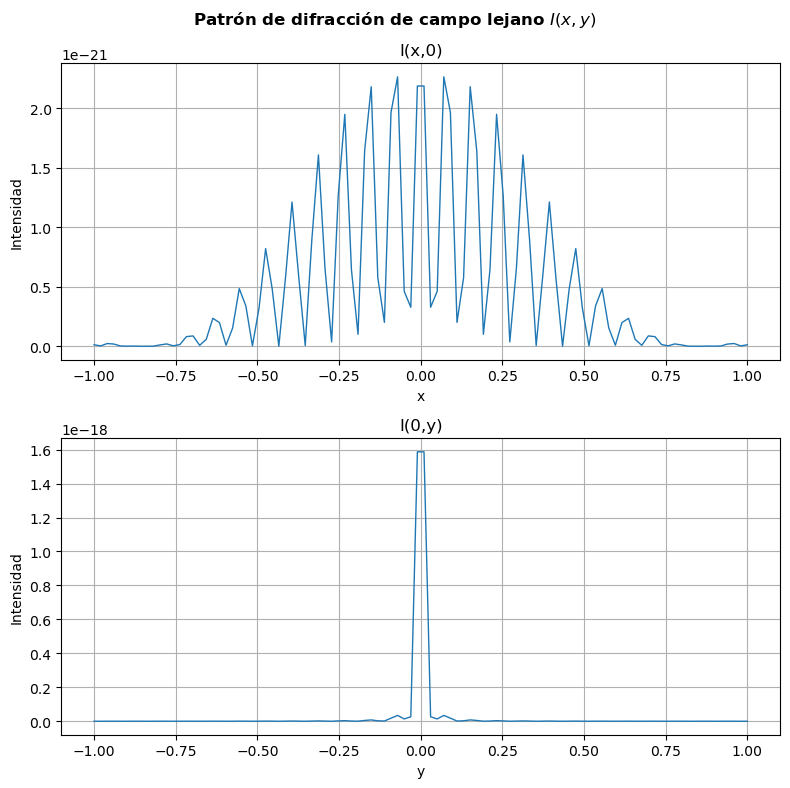

In [5]:
plot_axes(args, 1,100)

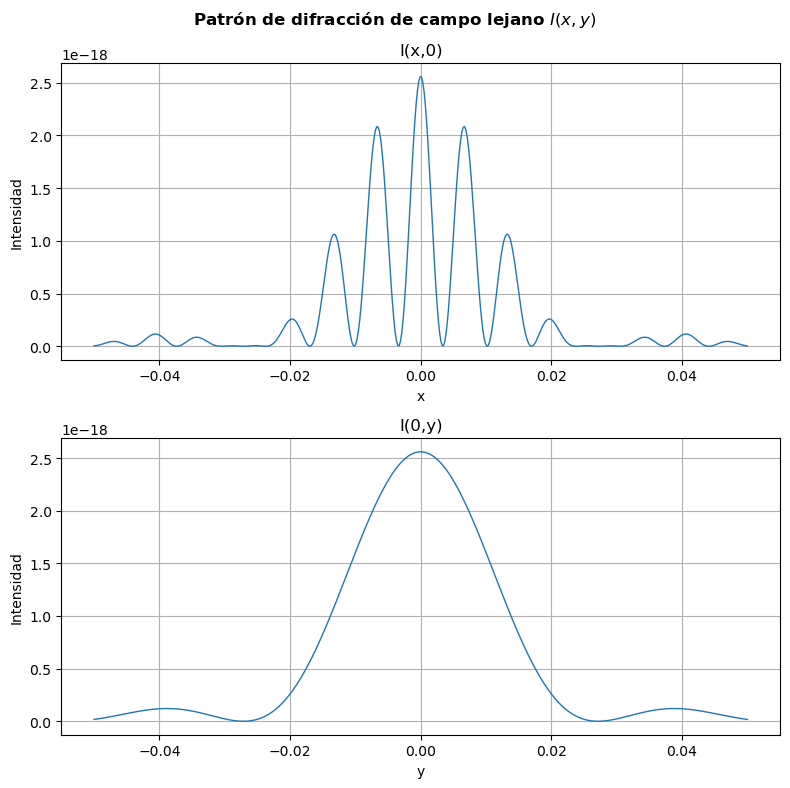

In [6]:
plot_axes(args, 0.05, 500)

In [7]:
''' Gráfica de I(x,y) '''
def plot_intensity(args, lim = 1, resolution = 100):
    X = np.linspace(-lim, lim, resolution) 
    Y = np.linspace(-lim, lim, resolution) 
    I = np.zeros([resolution, resolution])
    for i in range(len(X)):
        for j in range(len(Y)):
            I[j,i] = intensity(X[i],Y[j],args)
    x,y = np.meshgrid(X,Y)
    plt.figure(figsize=(8, 6))
    # Mapa de calor
    contour = plt.contourf(x,y, I, cmap='viridis', levels=100) 
    plt.colorbar(contour, label='Intensidad $I$')

    plt.title(f"Patrón de difracción de campo lejano $I(x,y)$", fontweight='bold')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

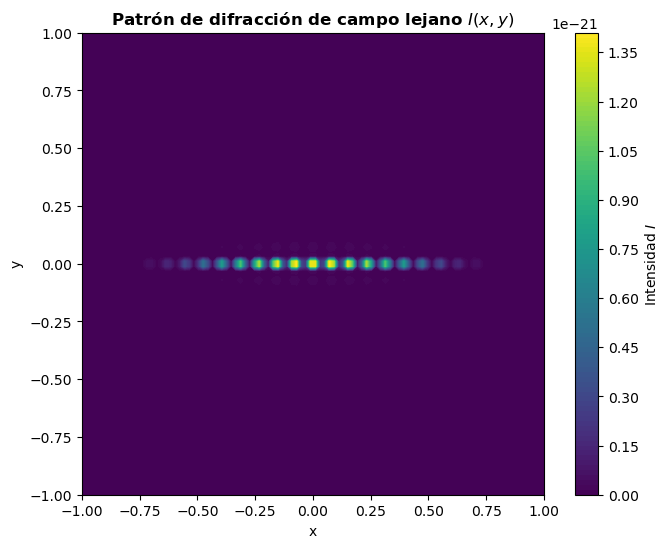

In [8]:
plot_intensity(args,1, 100)

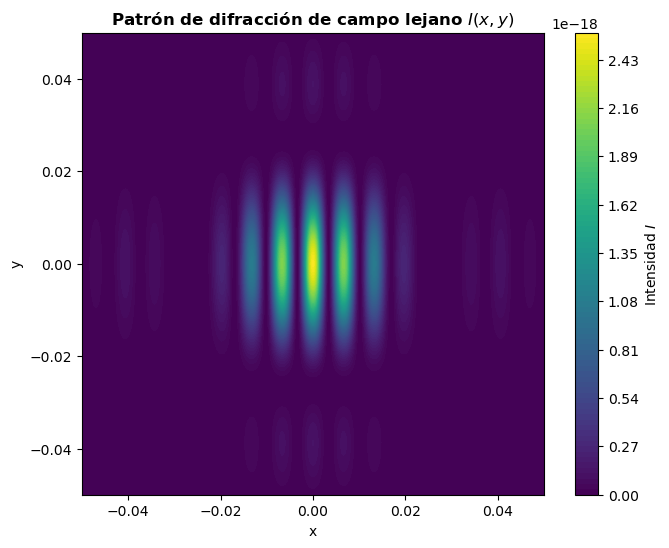

In [9]:
plot_intensity(args, 0.05,500)